# ProtoPNet – interpretable deep learning through prototypes

Na podstawie artykułu **Chen et al., 2019 – "This Looks Like That: Deep Learning for Interpretable Image Recognition"**.

Celem notebooka jest pokazanie, jak można zbudować model klasyfikacji obrazów,
który nie tylko osiąga wysoką dokładność, ale również potrafi wyjaśnić swoje decyzje
w sposób zrozumiały dla człowieka.

W kolejnych częściach notebooka zostaną przedstawione:

- opis i implementacja architektury
- trening modelu 
- wizualizacja prototypów
- interpretacja predykcji 

# Działanie i architektura modelu

ProtoPNet rozkłada obraz na fragmenty, wyszukuje prototypowe części obiektów i agreguje dowody dla każdej klasy. 

Model składa się z trzech głównych elementów:

### 1. Backbone CNN do ekstrakcji cech

Pierwsza część sieci to klasyczna sieć konwolucyjna (VGG, ResNet etc.), która przekształca obraz w embedding: image → CNN → embedding

### 2. Warstwa prototypów

Najważniejszym elementem modelu jest warstwa prototypów. Każdy prototyp reprezentuje charakterystyczny fragment obiektu dla danej klasy, np.:

- skrzydło ptaka
- dziób
- tłów

Najlpierw tworzymy prototypy, potem model oblicza podobieństwo między fragmentami obrazu a prototypami(embedding -> prototypes -> similarity). Im większe podobieństwo, tym większa aktywacja prototypu.

### 3. Warstwa klasyfikacji

Ostatnia warstwa modelu agreguje podobieństwa do prototypów i na ich podstawie podejmuje decyzję klasyfikacyjną: similarity → linear layer → prediction. Każdy prototyp dostarcza dowodów na rzecz danej klasy,a końcowa predykcja jest sumą tych dowodów. 

# Interpretacja predykcji

Największą zaletą ProtoPNet jest możliwość bezpośredniej interpretacji decyzji modelu na podstawie prototypów. Dla każdej predykcji możemy zobaczyć:

- który fragment obrazu aktywował prototyp
- który prototyp został użyty
- z jakiej klasy pochodzi ten prototyp


Dzięki temu użytkownik może łatwo zrozumieć, na jakich cechach obrazu model opiera swoją decyzję.

Schmat przedstawiający działanie modelu: 

<div style="text-align:center">

<img src="images/protopnet.png" width="1000">

<p style="font-size:14px">
Źródło:<a href="https://arxiv.org/pdf/1806.10574">
This Looks Like That: Deep Learning for Interpretable Image Recognition</a>
</p>

</div>

# Implementacja ProtoPNet

Model składa się z trzech głównych elementów:

## 1. **Backbone CNN** – do ekstrakcji reprezentacji obrazu


In [38]:
import torch
import torch.nn as nn
import torchvision.models as models

def get_backbone():
    """
    Funkcja usuwa ostatnią warstwę klasyfikacyjną ResNet18, aby uzyskać
    mapy cech do użycia w ProtoPNet.

    Parametry:
     Brak.
     
    Zwraca:
     nn.Module: ResNet18 bez ostatniej warstwy klasyfikacyjnej.
    """
    backbone = models.resnet18(pretrained=True)
    
    # usuwamy ostatnią warstwę klasyfikacyjną, aby otrzymać reprezentacje
    backbone = nn.Sequential(*list(backbone.children())[:-2])
    
    return backbone

## 2. **Prototype Layer** – do porównania fragmentów obrazu z prototypami

In [2]:
import torch
import torch.nn as nn

class PrototypeLayer(nn.Module):
    """
    Warstwa przechowująca uczone prototypy i obliczająca ich podobieństwo
    do mapy cech z sieci konwolucyjnej.
    """

    def __init__(self, num_prototypes: int, prototype_dim: int) -> None:
        """
        Parametry:
         num_prototypes - Liczba prototypów.
         prototype_dim - Wymiar prototypu, równy liczbie kanałów (C).
        """
        super().__init__()
        
        self.num_prototypes = num_prototypes
        
        # prototypy są parametrami modelu, prototype_dim = feature_dim z backbone
        self.prototypes = nn.Parameter(torch.rand(num_prototypes, prototype_dim))  
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parametry:
         x : Mapa cech [B, C, H, W].
        """
        B, C, H, W = x.shape

        # spłaszczamy patch'e: [B, H*W, C]
        patches = x.permute(0, 2, 3, 1).reshape(B, H*W, C)

        similarities = []

        for p in self.prototypes: 
            p = p.unsqueeze(0).unsqueeze(0)  
            # odległość L2 patchy do prototypu
            dists = torch.sum((patches - p)**2, dim=2) 
            # minimalna odległość patcha dla każdego obrazu
            min_dist, _ = torch.min(dists, dim=1)    
            # similarity = -distance
            similarities.append(-min_dist)

        similarities = torch.stack(similarities, dim=1)  # [B, num_prototypes]
        return similarities

## 3. **Linear Classification Layer** – agregacja dowodów z prototypów


In [79]:
class ProtoPNet(nn.Module):
    """
    Prosta implementacja sieci ProtoPNet: backbone ekstraktuje mapy cech,
    które są porównywane z prototypami, a następnie klasyfikowane.
    """
    def __init__(self, num_classes: int, num_prototypes: int = 20, prototype_dim: int = 512) -> None:
        """
        Parametry:
         num_classes - liczba klas klasyfikacji.
         num_prototypes - liczba prototypów w modelu.
         prototype_dim - wymiar prototypów.
        """
        super().__init__()
        
        self.num_classes = num_classes
        self.num_prototypes = num_prototypes
        
        self.backbone = get_backbone()
        self.prototype_layer = PrototypeLayer(
            num_prototypes,
            prototype_dim
        )
        self.classifier = nn.Linear(num_prototypes, num_classes)
        
        self.initialize_last_layer()
    
    def initialize_last_layer(self) -> None:
        """
        Inicjalizuje warstwę klasyfikatora - tak, aby każdy prototyp był
        początkowo przypisany do jednej klasy.
        """
        # każda klasa dostaje równą liczbę prototypów
        prototypes_per_class = self.num_prototypes // self.num_classes
        weight = torch.full((self.num_classes, self.num_prototypes), -0.5)
        for k in range(self.num_classes):
            start = k * prototypes_per_class
            end = (k + 1) * prototypes_per_class
            weight[k, start:end] = 1.0
        
        with torch.no_grad():
            self.classifier.weight.copy_(weight)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parametry:
         x - obraz wejściowy.
        Zwraca:
         logity klasyfikacji [B, num_classes].
        """
        features = self.backbone(x)
        similarity = self.prototype_layer(features)
        logits = self.classifier(similarity)
        return logits

## Przygotowanie datasetu i pipeline treningowego

W pracy ProtoPNet model trenowany był na datasetach
do szczegółowej klasyfikacji obrazów (fine-grained recognition), takich jak:

- **CUB-200-2011** – dataset ptaków
- **Stanford Cars** – klasyfikacja modeli samochodów

Natomiast, w eksperymentach autorów, najczęściej wykorzystywany jest
dataset **CUB-200-2011**, zawierający 11 000 obrazów praków z 200 klas (gatunków).

Uwaga: dataset zawiera wyłącznie etykiety klas, bez oznaczeń części obiektów. ProtoPNet sam uczy się tych prototypowych fragmentów obrazów podczas treningu.  

In [80]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

image_size = 224

train_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # normalizacja dla wybranego przez nas backbone - resnet18
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [81]:
import os
import tarfile
import urllib.request

url = "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz"
dataset_path = "dataset/CUB_200_2011.tgz"
extract_path = "dataset"

os.makedirs("dataset", exist_ok=True)

if not os.path.exists(dataset_path):
    print("Downloading CUB-200-2011...")
    urllib.request.urlretrieve(url, dataset_path)

print("Extracting dataset...")
with tarfile.open(dataset_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

print("Dataset ready.")

Extracting dataset...
Dataset ready.


In [82]:
import pandas as pd
import shutil

base_path = "dataset/CUB_200_2011"

images = pd.read_csv(
    f"{base_path}/images.txt",
    sep=" ",
    names=["img_id","filepath"]
)

labels = pd.read_csv(
    f"{base_path}/image_class_labels.txt",
    sep=" ",
    names=["img_id","target"]
)

split = pd.read_csv(
    f"{base_path}/train_test_split.txt",
    sep=" ",
    names=["img_id","is_train"]
)

data = images.merge(labels, on="img_id")
data = data.merge(split, on="img_id")

train_root = "dataset/train"
test_root = "dataset/test"

os.makedirs(train_root, exist_ok=True)
os.makedirs(test_root, exist_ok=True)

for _, row in data.iterrows():
    src = f"{base_path}/images/{row.filepath}"
    class_name = row.filepath.split("/")[0]
    if row.is_train == 1:
        dst_dir = os.path.join(train_root, class_name)
    else:
        dst_dir = os.path.join(test_root, class_name)
    os.makedirs(dst_dir, exist_ok=True)
    dst = os.path.join(dst_dir, os.path.basename(row.filepath))
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print("ImageFolder structure created.")



ImageFolder structure created.


In [83]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root="dataset/train",
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    root="dataset/test",
    transform=test_transforms
)

print("Number of classes:", len(train_dataset.classes))
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Number of classes: 200
Train samples: 5994
Test samples: 5794


In [84]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

### Funkcja straty 

Całkowita funkcja straty modelu ProtoPNet składa się z trzech składników:

$$
L = L_{cls} + \lambda_1 L_{cluster} + \lambda_2 L_{separation}
$$

gdzie:

- $L_{cls}$ – funkcja straty klasyfikacji (cross-entropy),
- $L_{cluster}$ – wymusza bliskość reprezentacji obrazów do prototypów tej samej klasy,
- $L_{separation}$ – wymusza oddalenie reprezentacji obrazów od prototypów innych klas,
- $\lambda_1, \lambda_2$ – współczynniki regularyzacji kontrolujące wpływ poszczególnych składników.

---

#### Classification loss

Funkcja klasyfikacji jest standardową funkcją **cross-entropy**:

$$
L_{cls} =
- \sum_{i=1}^{N}
\log
\frac{e^{f_{y_i}(x_i)}}
{\sum_{c=1}^{C} e^{f_c(x_i)}}
$$

gdzie:

- $x_i$ – obraz wejściowy,
- $y_i$ – prawdziwa etykieta klasy,
- $f_c(x_i)$ – logit modelu dla klasy $c$.

---

#### Cluster loss

Cluster loss zachęca, aby reprezentacja obrazu była **blisko prototypów swojej klasy**:

$$
L_{cluster} =
\frac{1}{N}
\sum_{i=1}^{N}
\min_{p_j \in P_{y_i}}
\| z_i - p_j \|_2^2
$$

gdzie:

- $z_i$ – reprezentacja obrazu w przestrzeni cech,
- $p_j$ – prototyp,
- $P_{y_i}$ – zbiór prototypów przypisanych do klasy $y_i$.

---

#### Separation loss

Separation loss wymusza, aby reprezentacja obrazu była **daleko od prototypów innych klas**:

$$
L_{separation} =
-
\frac{1}{N}
\sum_{i=1}^{N}
\min_{p_j \notin P_{y_i}}
\| z_i - p_j \|_2^2
$$

---

Dzięki tym trzem składnikom model jednocześnie:

- uczy się klasyfikować obrazy
- organizuje przestrzeń cech tak, aby obrazy były blisko prototypów swojej klasy a jednocześnie daleko od prototypów innych klas

In [85]:
def cluster_loss(similarity: torch.Tensor, labels: torch.Tensor, prototypes_per_class: int) -> torch.Tensor:
    """
    Funkcja straty cluster loss. Premiuje grupowanie obrazów jednej klasy w przestrzeni cech.

    Parametry:
     similarity: podobieństwa obrazów do prototypów.
     labels: etykiety klas dla obrazów w batchu.
     prototypes_per_class: liczba prototypów przypisanych do jednej klasy.

    Zwraca:
     Skalarn tensor - średnia wartość straty w batchu.
    """
    batch_size = similarity.shape[0]<p style="font-size:14px">
Źródło:<a href="https://arxiv.org/pdf/1602.04938">
“Why Should I Trust You?” Explaining the Predictions of Any Classifier
</a>
</p>
    loss = 0.0

    for i in range(batch_size):
        label = labels[i]

        start = label * prototypes_per_class
        end = (label + 1) * prototypes_per_class

        class_similarity = similarity[i, start:end]

        loss += -torch.max(class_similarity)

    return loss / batch_size

def separation_loss(similarity: torch.Tensor, labels: torch.Tensor, prototypes_per_class: int) -> torch.Tensor:
    """
    Funkcja straty separation loss. Premiuje rozdzielanie obrazów różnych klasy w przestrzeni cech .

    Parametry:
     similarity: podobieństwa obrazów do prototypów.
     labels: etykiety klas dla obrazów w batchu.
     prototypes_per_class: liczba prototypów przypisanych do jednej klasy.

    Zwraca:
     Skalarn tensor - średnia wartość straty w batchu.
    """    
    batch_size = similarity.shape[0]
    loss = 0.0

    for i in range(batch_size):
        label = labels[i]

        start = label * prototypes_per_class
        end = (label + 1) * prototypes_per_class

        other_similarity = torch.cat([
            similarity[i, :start],
            similarity[i, end:]
        ])

        loss += torch.max(other_similarity)

    return loss / batch_size

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)

model = ProtoPNet(
    num_classes=num_classes,
    # dla 200 klas - 10 prototypów na klasę
    num_prototypes=2000,
    # autorzy testowali rozmiary 128, 256, 512
    prototype_dim=512
).to(device)

In [94]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = torch.nn.CrossEntropyLoss()

def train_epoch(model: "ProtoPNet", loader: DataLoader, optimizer: optim.Optimizer) -> tuple[float, float]:
     """
    Trenuje model przez jedną epokę.

    Parametry:
     model: sieć z prototypami i backbone.
     loader: iterator po danych treningowych.
     optimizer: optymalizator modelu.

    Zwraca:
     tuple: (średnia strata w epoce, dokładność w epoce).
    """
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    prototypes_per_class = model.num_prototypes // model.num_classes

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        features = model.backbone(images)
        similarity = model.prototype_layer(features)
        logits = model.classifier(similarity)

        loss_cls = criterion(logits, labels)
        loss_cluster = cluster_loss(similarity, labels, prototypes_per_class)
        loss_sep = separation_loss(similarity, labels, prototypes_per_class)

        loss = loss_cls + 0.8 * loss_cluster + 0.1 * loss_sep

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, acc

def evaluate(model, loader: DataLoader) -> float:
    """
    Ocenia dokładność modelu na podanym zbiorze danych.

    Parametry:
     model: sieć z prototypami i backbone.
     loader: iterator po danych - walidacyjnych lub testowych.

    Zwraca:
     float: dokładność modelu na zbiorze.
    """    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            features = model.backbone(images)
            similarity = model.prototype_layer(features)
            logits = model.classifier(similarity)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

### Algorytm treningu 

Trening modelu jest podzielony na trzy główne etapy. Takie podejście pozwala najpierw nauczyć reprezentacji i prototypów, a dopiero później zoptymalizować końcową warstwę klasyfikującą w sposób bardziej stabilny i interpretowalny.

#### 1. Trening backbone i warstwy prototypów 

W pierwszym etapie uczone są wszystkie warstwy przed ostatnią warstwą klasyfikatora, czyli bacbone oraz prototype layer.
Ostatnia warstwa (klasyfikator) jest w tym kroku zamrożona.

#### 2. Projekcja prototypów (prototype push)

Po zakończeniu treningu wykonywana jest operacja projekcji prototypów, tzn. każdy prototyp jest zastępowany przez najbliższy fragment obrazu z dancyh treningowych, który należy do tej samej klasy.

Proces ten polega na:

1. Przepuszczeniu wszystkich obrazów treningowych przez sieć.
2. Obliczeniu podobieństwa między prototypem a wszystkimi patchami w mapach cech.
3. Znalezieniu patcha o najmniejszej odległości (największym podobieństwie).
4. Zastąpieniu prototypu reprezentacją tego patcha.

Dzięki temu prototypy odpowiadają rzeczywistym fragmentom obrazów, co zwiększa interpretowalność modelu.

#### 3. Optymalizacja ostatniej warstwy (convex optimization)

W trzecim etapie zamrażane są backbone i prototypy, a trenowana jest tylko ostatnia warstwa (klasyfikator). Tę warstwę można intuicyjne interpretować jako liniowy model, który decyduje, które prototypy są dowodem dla danej klasy.

Optymalizacja tej warstwy jest relatywnie prosta, ponieważ problem ma charakter wypukły.

#### Powtarzanie cyklu treningowego

Autorzy pracy zauważają, że cały proces może być powtarzany wielokrotnie. Pozwala to na dalsze dopasowanie reprezentacji i prototypów do danych. Przykład przedstawiony w notebooku przedstawia tylko jeden cykl ze względu na duży czas obliczeń.

## Czym jest "convex problem" (problem wypukły)?

Problem optymalizacji nazywamy wypukłym, jeśli minimalizowana funkcja straty jest funkcją wypukłą.

Funkcja $f(x)$ jest wypukła, jeśli dla dowolnych punktów $x_1$ i $x_2$ oraz $\lambda \in [0,1]$ zachodzi:

$$
f(\lambda x_1 + (1-\lambda)x_2)
\le
\lambda f(x_1) + (1-\lambda)f(x_2)
$$

Intuicyjnie oznacza to, że wykres funkcji ma kształt miski (ang. bowl-shaped).

W takiej funkcji:

- istnieje jedno globalne minimum
- nie ma wielu lokalnych minimów
- metody gradientowe prowadzą do tego samego rozwiązania

Grafika przedstawiająca funkcje niewypukłą i wypukłą:

<div style="text-align:center">

<img src="images/convex.png" width="750">

<p style="font-size:14px">
Źródło: <a href="https://thedatacopywriter.substack.com/p/what-is-a-convex-function">
What is a convex function?
</a>
</p>

</div>

---

## Dlaczego optymalizacja ostatniej warstwy jest problemem wypukłym?

Ponieważ trzecim etapie treningu zamrażane są wszystkie wcześniejsze części modelu tzn. backbone i warstwa prototypów, to dla każdego obrazu wartości podobieństwa do prototypów są już stał* i nie zmieniają się podczas dalszego uczenia.

Dla obrazu $x$ model oblicza wektor podobieństw do prototypów:

$$
s(x) = (s_1(x), s_2(x), ..., s_P(x))
$$

gdzie $s_i(x)$ oznacza podobieństwo obrazu do $i$-tego prototypu.

Ostatnia warstwa modelu jest warstwą liniową, która przekształca ten wektor podobieństw w logity klas:

$$
z_k(x) =
\sum_{j=1}^{P} w_{k,j} \, s_j(x)
$$

gdzie:

- $w_{k,j}$ – waga łącząca prototyp $j$ z klasą $k$
- $P$ – liczba prototypów
- $z_k(x)$ – logit (surowy wynik) dla klasy $k$

W tym momencie model działa więc jak liniowy klasyfikator. Redukuje się więc do postaci:

$$
z = W s(x)
$$

gdzie $W$ to macierz wag.

Funkcja straty zależy jedynie od tych wag oraz stałych cech $s(x)$.

Ponieważ model jest liniowy względem wag i wykorzystany loss jest funkcją wypukłą względem logitów to cały problem optymalizacji wag staje się problemem wypukłym.

---

## Intuicja

Ostatnia warstwa uczy się "reguł":

- „jeśli obraz jest podobny do prototypu skrzydła → zwiększ prawdopodobieństwo klasy ptak”
- „jeśli obraz jest podobny do prototypu koła → zwiększ prawdopodobieństwo klasy samochód”

---

## Dlaczego robi się to jako osobny etap treningu

Gdyby ostatnia warstwa była trenowana jednocześnie z backbone'em i prototypami, przestrzeń cech zmieniałaby się w trakcie treningu, co utrudniałoby stabilną optymalizację. Oddzielenie tego etapu powoduje, że:

1. reprezentacja obrazów jest już ustalona  
2. prototypy odpowiadają rzeczywistym fragmentom obrazów  
3. klasyfikator uczy się jedynie najlepszej kombinacji prototypów

Dzięki temu trening ostatniej warstwy jest stabilny, szybki i łatwy do interpretacji.

In [46]:
@torch.no_grad()
def prototype_push(model, loader: DataLoader) -> None:
    """
    Wykonuje operację 'prototype pushing', tj. przesuwa każdy prototyp
    w kierunku najbardziej podobnego patcha swojej klasy w zbiorze danych.

    Parametry:
     model: sieć zawierająca prototypy i backbone.
     loader: iterator po danych wejściowych z etykietami.

    Zwraca:
     None. Prototypy w modelu są aktualizowane in-place.
    """
    model.eval()

    num_prototypes = model.num_prototypes
    feature_dim = model.prototype_layer.prototypes.shape[1]

    all_patches = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        features = model.backbone(images) 

        B, C, H, W = features.shape
        features = features.permute(0, 2, 3, 1).reshape(B*H*W, C)  
        labels = labels.unsqueeze(1).repeat(1, H*W).reshape(-1) 

        all_patches.append(features)
        all_labels.append(labels)

    all_patches = torch.cat(all_patches, dim=0)  
    all_labels = torch.cat(all_labels, dim=0)

    prototypes_per_class = num_prototypes // model.num_classes

    for j in range(num_prototypes):
        class_j = j // prototypes_per_class

        class_mask = (all_labels == class_j)
        features_class = all_patches[class_mask]

        proto = model.prototype_layer.prototypes[j].unsqueeze(0) 

        distances = torch.cdist(features_class, proto)  
        closest_idx = torch.argmin(distances)

        # aktualizacja prototypu
        model.prototype_layer.prototypes[j] = features_class[closest_idx]

[Step 1] Epoch 1/30 - Loss: 3.7691, Train Acc: 0.1603, Test Acc: 0.1700
[Step 1] Epoch 2/30 - Loss: 3.4696, Train Acc: 0.2184, Test Acc: 0.1919
[Step 1] Epoch 3/30 - Loss: 3.2962, Train Acc: 0.2533, Test Acc: 0.2185
[Step 1] Epoch 4/30 - Loss: 3.0618, Train Acc: 0.3011, Test Acc: 0.2703
[Step 1] Epoch 5/30 - Loss: 2.8466, Train Acc: 0.3575, Test Acc: 0.2953
[Step 1] Epoch 6/30 - Loss: 2.6686, Train Acc: 0.3307, Test Acc: 0.3027
[Step 1] Epoch 7/30 - Loss: 2.3258, Train Acc: 0.4117, Test Acc: 0.3195
[Step 1] Epoch 8/30 - Loss: 2.1169, Train Acc: 0.4648, Test Acc: 0.3612
[Step 1] Epoch 9/30 - Loss: 1.8529, Train Acc: 0.5350, Test Acc: 0.3878
[Step 1] Epoch 10/30 - Loss: 1.7236, Train Acc: 0.5749, Test Acc: 0.4101
[Step 1] Epoch 11/30 - Loss: 1.7403, Train Acc: 0.5494, Test Acc: 0.4215
[Step 1] Epoch 12/30 - Loss: 1.4650, Train Acc: 0.6260, Test Acc: 0.4355
[Step 1] Epoch 13/30 - Loss: 1.2716, Train Acc: 0.6864, Test Acc: 0.4422
[Step 1] Epoch 14/30 - Loss: 1.1142, Train Acc: 0.7382, Test

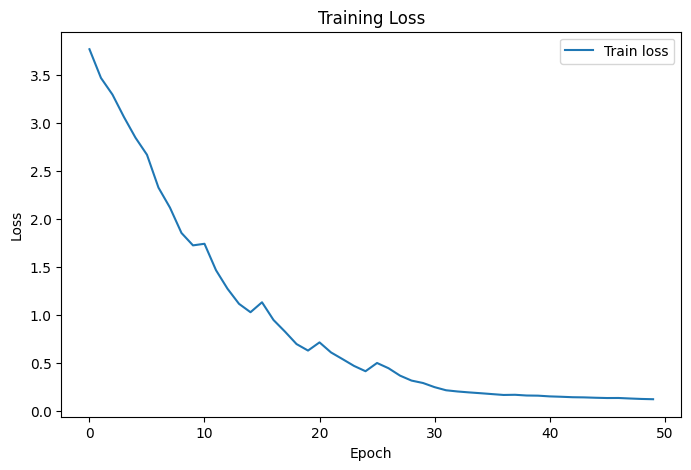

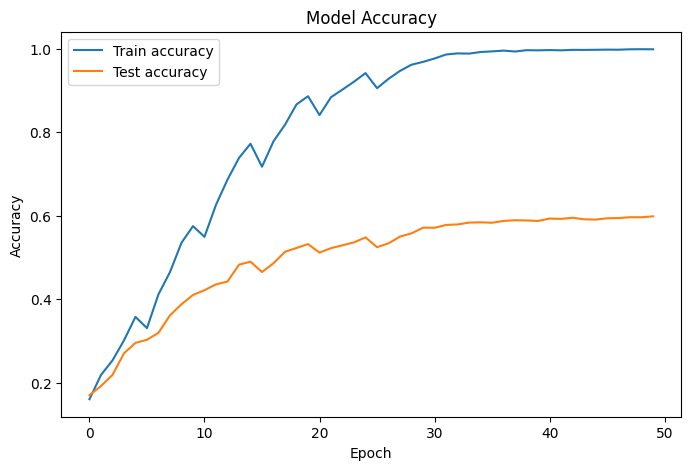

In [98]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

num_epochs_step1 = 30
num_epochs_step2 = 20

train_losses, train_accuracies, test_accuracies = [], [], []

# Step 1 - trenowanie prototypów i backbone
optimizer_step1 = optim.Adam(
    list(model.backbone.parameters()) + list(model.prototype_layer.parameters()),
    lr=1e-4
)

for epoch in range(num_epochs_step1):

    loss, acc = train_epoch(model, train_loader, optimizer_step1)
    train_losses.append(loss)
    train_accuracies.append(acc)

    test_acc = evaluate(model, test_loader)
    test_accuracies.append(test_acc)

    print(f"[Step 1] Epoch {epoch+1}/{num_epochs_step1} - Loss: {loss:.4f}, Train Acc: {acc:.4f}, Test Acc: {test_acc:.4f}")


prototype_push(model, train_loader)

# Step 2 - trening klasyfikatora
for param in model.backbone.parameters():
    param.requires_grad = False

for param in model.prototype_layer.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

optimizer_step2 = optim.Adam(
    model.classifier.parameters(),
    lr=1e-5
)

for epoch in range(num_epochs_step2):

    loss, acc = train_epoch(model, train_loader, optimizer_step2)
    train_losses.append(loss)
    train_accuracies.append(acc)

    test_acc = evaluate(model, test_loader)
    test_accuracies.append(test_acc)

    print(f"[Step 2] Epoch {epoch+1}/{num_epochs_step2} - Loss: {loss:.4f}, Train Acc: {acc:.4f}, Test Acc: {test_acc:.4f}")

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Train accuracy")
plt.plot(test_accuracies, label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

In [141]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

def visualize_prototype_activation(image: torch.Tensor, model, mean: list[float] | None = None, std: list[float] | None = None) -> int:
    """
    Wizualizuje najbardziej aktywny prototyp na obrazie.

    Parametry:
     image:  obraz wejściowy.
     model: sieć z prototypami i backbone.
     mean: średnie do odnormalizacji obrazu (lub None).
     std: odchylenia standardowe do odnormalizacji (lub None).

    Zwraca:
     int: ID prototypu o największej aktywacji dla danego obrazu.
    """    model.eval()
    device = next(model.parameters()).device

    # "od-normalizacja" obrazu
    def denormalize(img):
        img = img.cpu().numpy().transpose(1,2,0)
        if mean is not None and std is not None:
            mean_arr = np.array(mean)
            std_arr  = np.array(std)
            img = img * std_arr + mean_arr
        return np.clip(img, 0, 1)

    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        features = model.backbone(x)  # [1,C,Hf,Wf]
        _, C, Hf, Wf = features.shape
        img_h, img_w = image.shape[1], image.shape[2]

        # liczenie similarity mapy 
        prototypes = model.prototype_layer.prototypes  
        num_prototypes = prototypes.shape[0]

        patches_feat = features.permute(0,2,3,1).reshape(-1, C)  
        distances = torch.cdist(patches_feat, prototypes)        
        similarity_map = -distances.view(1, Hf, Wf, num_prototypes).permute(0,3,1,2)  

        # wybór prototypu o największej maksymalnej aktywacji
        max_acts = similarity_map.view(num_prototypes, -1).max(dim=1).values
        prototype_id = torch.argmax(max_acts).item()

        proto_map = similarity_map[0, prototype_id]
        proto_map = proto_map.squeeze()

        # obsługa różnych wymiarów mapy
        if proto_map.ndim == 0:
            h_idx, w_idx = 0, 0
        elif proto_map.ndim == 1:
            h_idx = int(torch.argmax(proto_map))
            w_idx = 0
        else:
            flat_idx = torch.argmax(proto_map)
            h_idx, w_idx = int(flat_idx // proto_map.shape[1]), int(flat_idx % proto_map.shape[1])


        # przeliczenie współrzędnych na piksele w obrazie
        h_center = int((h_idx + 0.5) * img_h / Hf)
        w_center = int((w_idx + 0.5) * img_w / Wf)
        rect_h = int(img_h / Hf)
        rect_w = int(img_w / Wf)

        h_start = max(0, h_center - rect_h // 2)
        w_start = max(0, w_center - rect_w // 2)
        h_end = min(img_h, h_start + rect_h)
        w_end = min(img_w, w_start + rect_w)

        img_show = denormalize(image)

        # oznaczenie prototypu
        fig, ax = plt.subplots(figsize=(5,5))
        ax.imshow(img_show)
        rect = patches.Rectangle(
            (w_start, h_start),
            w_end - w_start,
            h_end - h_start,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.set_title(f"Prototype {prototype_id}")
        ax.axis('off')
        plt.show()

    return prototype_id

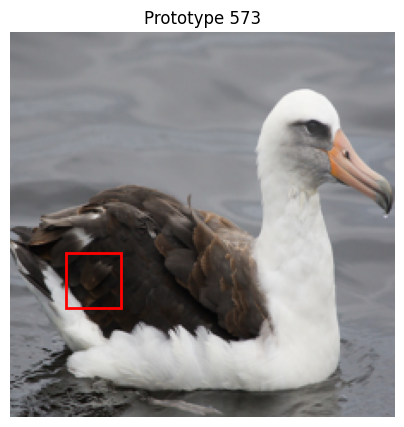

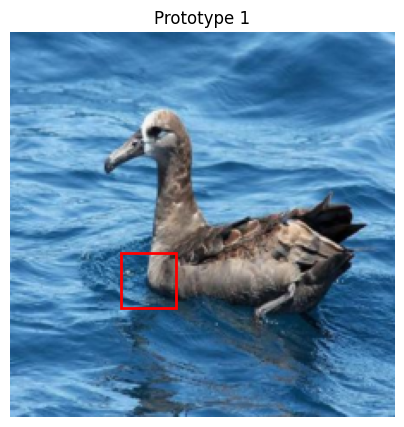

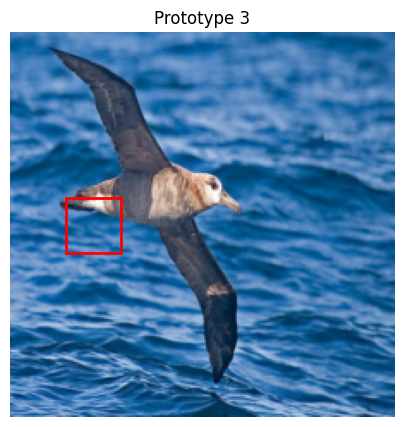

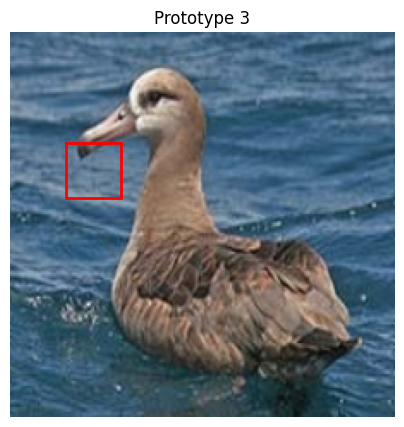

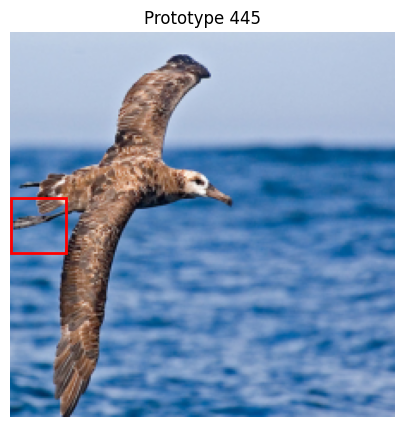

In [194]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

import random
num_samples = 5
indices = random.sample(range(len(test_dataset)), num_samples)
images = [test[i][0] for i in indices]

for i, img in enumerate(images):
    proto_id = visualize_prototype_activation_debug_fixed(img, model, mean=mean, std=std)


## Zadanie 2 (nieobowiązkowe)

Aby utrwalić wiedzę o modelu ProtoPNet zapoznaj się z artykułem:
<p style="font-size:14px">
<a href="https://www.emergentmind.com/papers/1806.10574">
"ProtoPNet: Interpretability in Image Recognition" </a>
</p>
oraz ilustracjami działania sieci. Na ich podstawie odpowiedz na następujące pytania:

1. Opisz, czym jest ProtoPNet i w jaki sposób różni się od standardowych sieci konwolucyjnych pod względem interpretowalności.

2. Wyjaśnij krok po kroku, jak ProtoPNet wykorzystuje prototypy do podejmowania decyzji klasyfikacyjnych.

3. Na wybranym przykładzie obrazu z artykułu wskaż, które prototypy zostały aktywowane i jak wpłynęły one na ostateczną decyzję modelu.

4. Opisz, jakie są zalety i ograniczenia podejścia prototypowego w porównaniu do metod post‑hoc (np. Grad‑CAM).